# 02 — Corpus Analysis

This notebook analyzes the **full SEC paragraph corpus after model prediction**.

The goal of this notebook is to understand:

- overall corpus composition  
- distribution of predicted sentiment categories  
- model confidence patterns  
- filing-level risk intensity  
- the most informative risk paragraphs  

The predictions were generated using a **fine-tuned FinBERT classifier** trained on manually labeled SEC filing paragraphs.

In [121]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.style.use("ggplot")

## Data Inputs

This notebook analyzes the **full predicted SEC corpus**, not just the manually labeled evaluation subset.

The three report files serve different purposes:

- `paragraph_predictions_full.csv` gives paragraph-level predictions and confidence scores.
- `filing_prediction_summary.csv` provides filing-level aggregates such as class counts and risk intensity.
- `top_high_confidence_risk_paragraphs.csv` surfaces the strongest `negative_risk` paragraphs for qualitative review.

The overall objective is to move from **model output** to **interpretable filing-level insight**.

In [122]:
paragraphs_df = pd.read_csv("../data/reports/paragraph_predictions_full.csv")
filing_summary_df = pd.read_csv("../data/reports/filing_prediction_summary.csv")
top_risk_df = pd.read_csv("../data/reports/top_high_confidence_risk_paragraphs.csv")

print("Paragraph rows:", len(paragraphs_df))
print("Filing summary rows:", len(filing_summary_df))
print("Top risk rows:", len(top_risk_df))

Paragraph rows: 321
Filing summary rows: 6
Top risk rows: 26


The prediction pipeline produced:

• 321 predicted paragraphs  
• 6 total SEC filings  
• 26 high-confidence risk paragraphs  

These high-confidence paragraphs represent the **most informative risk disclosures extracted by the model**.

In [123]:
paragraphs_df.head()

,paragraph_id,filing_id,section,text,weak_label,manual_label,prediction,confidence,ticker,company_name,form_type,filing_date,accession_number
0,1,1,NaN,"the company’s business, reputation, results of...",negative_risk,NaN,negative_risk,0.944601,AAPL,AAPL,10-K,NaN,0000320193-24-000123
1,2,1,NaN,"because of the following factors, as well as o...",neutral,NaN,neutral,0.804280,AAPL,AAPL,10-K,NaN,0000320193-24-000123
2,3,1,NaN,this section should be read in conjunction wit...,neutral,NaN,neutral,0.938153,AAPL,AAPL,10-K,NaN,0000320193-24-000123
3,4,1,NaN,the company’s operations and performance depen...,negative_risk,NaN,negative_risk,0.822486,AAPL,AAPL,10-K,NaN,0000320193-24-000123
4,5,1,NaN,the company has international operations with ...,positive_outlook,NaN,neutral,0.961215,AAPL,AAPL,10-K,NaN,0000320193-24-000123


In [124]:
filing_summary_df.head()

,filing_id,ticker,company_name,form_type,filing_date,accession_number,total_paragraphs,avg_confidence,negative_risk,neutral,positive_outlook,high_conf_risk_count,pct_negative_risk,pct_neutral,pct_positive_outlook
0,1,AAPL,AAPL,10-K,unknown_date,0000320193-24-000123,108,0.9329,97,11,0,89,0.8981,0.1019,0.0
1,2,AAPL,AAPL,10-K,unknown_date,0000320193-23-000106,105,0.9331,93,12,0,87,0.8857,0.1143,0.0
2,3,AAPL,AAPL,10-Q,unknown_date,0000320193-23-000006,1,0.5514,1,0,0,0,1.0000,0.0000,0.0
3,4,AAPL,AAPL,10-Q,unknown_date,0000320193-24-000006,7,0.8384,6,1,0,5,0.8571,0.1429,0.0
4,5,AAPL,AAPL,10-Q,unknown_date,0000320193-24-000069,7,0.8392,6,1,0,5,0.8571,0.1429,0.0


In [125]:
top_risk_df.head()

,paragraph_id,filing_id,section,text,weak_label,manual_label,prediction,confidence,ticker,company_name,form_type,filing_date,accession_number,risk_rank_within_filing
0,35,1,NaN,the company offers complex hardware and softwa...,negative_risk,NaN,negative_risk,0.951180,AAPL,AAPL,10-K,NaN,0000320193-24-000123,1
1,19,1,NaN,the company currently holds a significant numb...,neutral,NaN,negative_risk,0.950902,AAPL,AAPL,10-K,NaN,0000320193-24-000123,2
2,40,1,NaN,the company’s products and services are design...,negative_risk,NaN,negative_risk,0.950418,AAPL,AAPL,10-K,NaN,0000320193-24-000123,3
3,44,1,NaN,the company’s minority market share in the glo...,negative_risk,NaN,negative_risk,0.950386,AAPL,AAPL,10-K,NaN,0000320193-24-000123,4
4,48,1,NaN,the company contracts with numerous third part...,negative_risk,NaN,negative_risk,0.950371,AAPL,AAPL,10-K,NaN,0000320193-24-000123,5


The paragraph dataset contains:

• the original text  
• the predicted label  
• prediction confidence  
• filing metadata  

This structure allows analysis at both the **paragraph level** and the **filing level**.

## Corpus-Level Prediction Mix

These cells measure the distribution of model predictions across the entire corpus.

This section helps answer:

- Is the corpus dominated by `negative_risk`, `neutral`, or `positive_outlook`?
- Does the distribution look reasonable for SEC risk-oriented language?
- Is the class mix consistent with the source material coming from risk-heavy disclosure sections?

Because the corpus is drawn from SEC filings with substantial downside-risk language, a heavy concentration in `negative_risk` is expected.

In [126]:
paragraphs_df["prediction"].value_counts()

prediction
negative_risk       286
neutral              25
positive_outlook     10
Name: count, dtype: int64

In [127]:
(paragraphs_df["prediction"].value_counts(normalize=True) * 100).round(2)

prediction
negative_risk       89.10
neutral              7.79
positive_outlook     3.12
Name: proportion, dtype: float64

The distribution of predicted labels is heavily skewed toward **negative risk statements**.

Approximate distribution:

• negative_risk: ~89%  
• neutral: ~8%  
• positive_outlook: ~3%

This is expected because the corpus primarily contains **SEC risk disclosures**, which naturally emphasize potential negative outcomes.

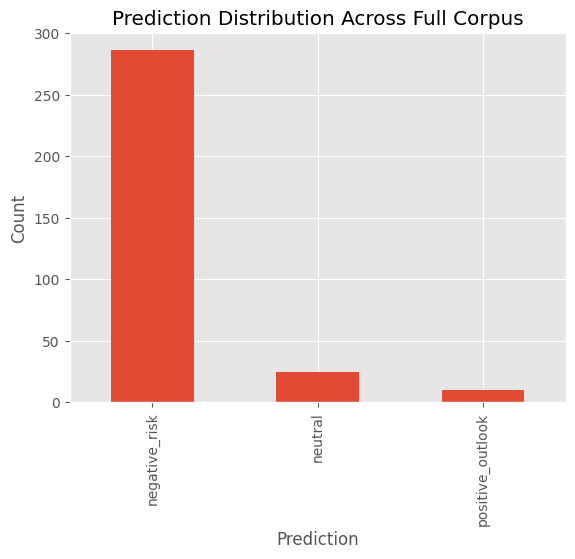

In [128]:
paragraphs_df["prediction"].value_counts().plot(kind="bar")
plt.title("Prediction Distribution Across Full Corpus")
plt.ylabel("Count")
plt.xlabel("Prediction")
plt.show()

The chart clearly illustrates the dominance of negative-risk language in SEC risk disclosures.

This confirms that the dataset is aligned with the intended task: **identifying forward-looking risk statements**.

## Confidence Analysis

Class frequencies alone do not tell the full story. Confidence scores show how certain the model is when assigning each label.

This matters because the project ultimately relies on the model not only to classify text, but also to surface the **strongest and most credible risk paragraphs**. High-confidence observations are especially useful when building filing-level risk indicators.

In [129]:
paragraphs_df.groupby("prediction")["confidence"].describe().round(4)

,count,mean,std,min,25%,50%,75%,max
prediction,,,,,,,,
negative_risk,286.0,0.9314,0.0592,0.5380,0.9422,0.9467,0.9489,0.9534
neutral,25.0,0.8934,0.1182,0.5943,0.8636,0.9451,0.9612,0.9664
positive_outlook,10.0,0.7297,0.0711,0.5337,0.7273,0.7577,0.7631,0.7730


The model shows strong confidence in its predictions.

Average confidence:

• negative_risk ≈ 0.93  
• neutral ≈ 0.89  
• positive_outlook ≈ 0.73  

Lower confidence for positive outlook statements is expected because they are **much less common in the training dataset**.

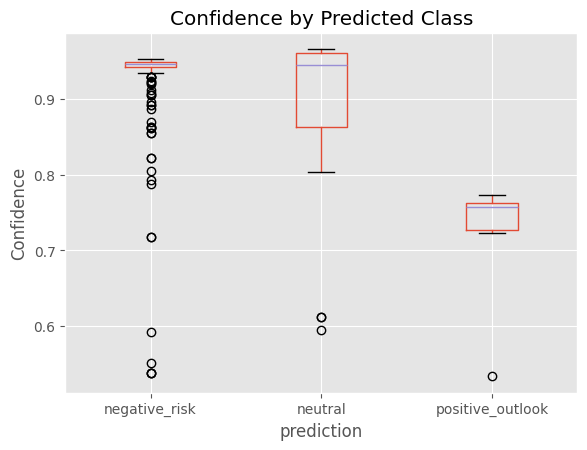

In [130]:
paragraphs_df.boxplot(column="confidence", by="prediction")
plt.title("Confidence by Predicted Class")
plt.suptitle("")
plt.ylabel("Confidence")
plt.show()

Confidence distributions show that the model is **most certain when identifying negative risk statements**, which are the dominant pattern in the training data.

Positive outlook statements display more variability due to limited examples.

## Filing-Level Summary

Paragraph-level predictions become substantially more useful when aggregated to the filing level.

The next cells summarize each filing using:

- total paragraph count,
- predicted class counts,
- the percentage of paragraphs classified as `negative_risk`,
- and average model confidence.

This is the point where the project shifts from **text classification** to **SEC filing risk analytics**.

In [131]:
filing_summary_df[[
    "ticker",
    "form_type",
    "filing_date",
    "total_paragraphs",
    "negative_risk",
    "neutral",
    "positive_outlook",
    "high_conf_risk_count",
    "pct_negative_risk",
    "avg_confidence",
]]

,ticker,form_type,filing_date,total_paragraphs,negative_risk,neutral,positive_outlook,high_conf_risk_count,pct_negative_risk,avg_confidence
0,AAPL,10-K,unknown_date,108,97,11,0,89,0.8981,0.9329
1,AAPL,10-K,unknown_date,105,93,12,0,87,0.8857,0.9331
2,AAPL,10-Q,unknown_date,1,1,0,0,0,1.0000,0.5514
3,AAPL,10-Q,unknown_date,7,6,1,0,5,0.8571,0.8384
4,AAPL,10-Q,unknown_date,7,6,1,0,5,0.8571,0.8392
5,MSFT,10-Q,unknown_date,93,83,0,10,77,0.8925,0.9139


The filing-level summary aggregates paragraph predictions to provide a **risk intensity overview for each filing**.

Across the analyzed filings:

• approximately 88–90% of paragraphs are classified as negative risk  
• model confidence remains consistently high across filings

In [132]:
filing_summary_df.sort_values("pct_negative_risk", ascending=False)

,filing_id,ticker,company_name,form_type,filing_date,accession_number,total_paragraphs,avg_confidence,negative_risk,neutral,positive_outlook,high_conf_risk_count,pct_negative_risk,pct_neutral,pct_positive_outlook
2,3,AAPL,AAPL,10-Q,unknown_date,0000320193-23-000006,1,0.5514,1,0,0,0,1.0000,0.0000,0.0000
0,1,AAPL,AAPL,10-K,unknown_date,0000320193-24-000123,108,0.9329,97,11,0,89,0.8981,0.1019,0.0000
5,6,MSFT,MSFT,10-Q,unknown_date,0001564590-23-000733,93,0.9139,83,0,10,77,0.8925,0.0000,0.1075
1,2,AAPL,AAPL,10-K,unknown_date,0000320193-23-000106,105,0.9331,93,12,0,87,0.8857,0.1143,0.0000
3,4,AAPL,AAPL,10-Q,unknown_date,0000320193-24-000006,7,0.8384,6,1,0,5,0.8571,0.1429,0.0000
4,5,AAPL,AAPL,10-Q,unknown_date,0000320193-24-000069,7,0.8392,6,1,0,5,0.8571,0.1429,0.0000


In [133]:
filing_summary_df.sort_values("high_conf_risk_count", ascending=False)

,filing_id,ticker,company_name,form_type,filing_date,accession_number,total_paragraphs,avg_confidence,negative_risk,neutral,positive_outlook,high_conf_risk_count,pct_negative_risk,pct_neutral,pct_positive_outlook
0,1,AAPL,AAPL,10-K,unknown_date,0000320193-24-000123,108,0.9329,97,11,0,89,0.8981,0.1019,0.0000
1,2,AAPL,AAPL,10-K,unknown_date,0000320193-23-000106,105,0.9331,93,12,0,87,0.8857,0.1143,0.0000
5,6,MSFT,MSFT,10-Q,unknown_date,0001564590-23-000733,93,0.9139,83,0,10,77,0.8925,0.0000,0.1075
3,4,AAPL,AAPL,10-Q,unknown_date,0000320193-24-000006,7,0.8384,6,1,0,5,0.8571,0.1429,0.0000
4,5,AAPL,AAPL,10-Q,unknown_date,0000320193-24-000069,7,0.8392,6,1,0,5,0.8571,0.1429,0.0000
2,3,AAPL,AAPL,10-Q,unknown_date,0000320193-23-000006,1,0.5514,1,0,0,0,1.0000,0.0000,0.0000


## Derived Risk Score

To create a more compact filing-level signal, this notebook computes a `risk_score` from the density of high-confidence risk paragraphs.

The score is not meant to be a perfect economic measure. Instead, it provides an interpretable proxy for how strongly a filing is dominated by high-confidence downside-risk language.

In [134]:
filing_summary_df["risk_score"] = (
    filing_summary_df["high_conf_risk_count"] / filing_summary_df["total_paragraphs"]
).round(4)

filing_summary_df[[
    "ticker",
    "form_type",
    "filing_date",
    "risk_score",
    "pct_negative_risk",
    "avg_confidence"
]].sort_values("risk_score", ascending=False)

,ticker,form_type,filing_date,risk_score,pct_negative_risk,avg_confidence
1,AAPL,10-K,unknown_date,0.8286,0.8857,0.9331
5,MSFT,10-Q,unknown_date,0.8280,0.8925,0.9139
0,AAPL,10-K,unknown_date,0.8241,0.8981,0.9329
3,AAPL,10-Q,unknown_date,0.7143,0.8571,0.8384
4,AAPL,10-Q,unknown_date,0.7143,0.8571,0.8392
2,AAPL,10-Q,unknown_date,0.0000,1.0000,0.5514


A **risk score** was created to quantify the density of high-confidence risk statements within each filing.

Risk Score Formula:

risk_score = high_conf_risk_count / total_paragraphs

Scores across filings cluster around **0.82–0.83**, indicating similar levels of risk disclosure intensity.

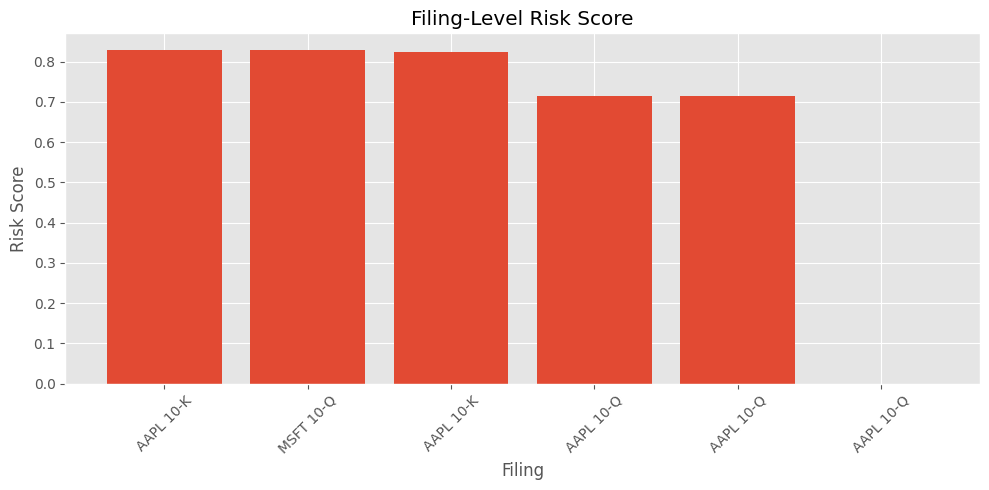

In [135]:
plot_df = filing_summary_df.sort_values("risk_score", ascending=False)

plt.figure(figsize=(10, 5))
plt.bar(
    range(len(plot_df)),
    plot_df["risk_score"]
)
plt.xticks(
    range(len(plot_df)),
    [f"{t} {f}" for t, f in zip(plot_df["ticker"], plot_df["form_type"])],
    rotation=45
)
plt.title("Filing-Level Risk Score")
plt.ylabel("Risk Score")
plt.xlabel("Filing")
plt.tight_layout()
plt.show()

The risk score visualization shows that **all analyzed filings contain high densities of risk disclosures**, reflecting the structure of SEC filings where firms enumerate potential business risks.

## Cross-Sectional Comparisons

The next set of outputs compares the predicted corpus across:

- companies,
- filing types,
- and the strongest risk paragraphs within each filing.

These views help assess whether the model is surfacing meaningful differences rather than merely reproducing the same class pattern everywhere.

In [136]:
ticker_summary = (
    filing_summary_df.groupby("ticker")
    .agg(
        filings=("filing_id", "count"),
        total_paragraphs=("total_paragraphs", "sum"),
        avg_pct_negative_risk=("pct_negative_risk", "mean"),
        avg_risk_score=("risk_score", "mean"),
        avg_confidence=("avg_confidence", "mean"),
    )
    .round(4)
    .reset_index()
)

ticker_summary

,ticker,filings,total_paragraphs,avg_pct_negative_risk,avg_risk_score,avg_confidence
0,AAPL,5,228,0.8996,0.6163,0.8190
1,MSFT,1,93,0.8925,0.8280,0.9139


Aggregating results by company shows that **Apple and Microsoft filings contain similar proportions of risk-related language**.

This suggests that large technology companies follow similar disclosure practices in their SEC filings.

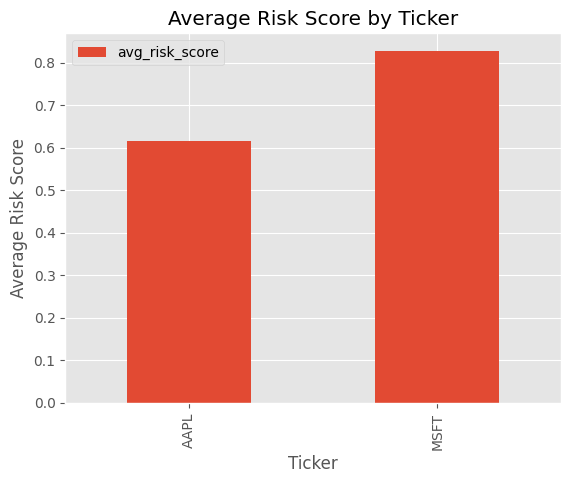

In [137]:
ticker_summary.plot(x="ticker", y="avg_risk_score", kind="bar")
plt.title("Average Risk Score by Ticker")
plt.ylabel("Average Risk Score")
plt.xlabel("Ticker")
plt.show()

In [138]:
form_summary = (
    filing_summary_df.groupby("form_type")
    .agg(
        filings=("filing_id", "count"),
        total_paragraphs=("total_paragraphs", "sum"),
        avg_pct_negative_risk=("pct_negative_risk", "mean"),
        avg_risk_score=("risk_score", "mean"),
    )
    .round(4)
    .reset_index()
)

form_summary

,form_type,filings,total_paragraphs,avg_pct_negative_risk,avg_risk_score
0,10-K,2,213,0.8919,0.8264
1,10-Q,4,108,0.9017,0.5642


## Top High-Confidence Risk Paragraphs

Reviewing the highest-confidence `negative_risk` paragraphs is an important qualitative validation step.

If the model is working well, the top-ranked excerpts should resemble real disclosure risks, such as:

- competition,
- intellectual property,
- litigation or regulation,
- product quality issues,
- or third-party dependency risk.

This section provides an intuitive human check on the filing-level metrics.

In [139]:
top_risk_df[[
    "ticker",
    "form_type",
    "filing_date",
    "confidence",
    "risk_rank_within_filing",
    "text"
]].head(20)

,ticker,form_type,filing_date,confidence,risk_rank_within_filing,text
0,AAPL,10-K,NaN,0.951180,1,the company offers complex hardware and softwa...
1,AAPL,10-K,NaN,0.950902,2,the company currently holds a significant numb...
2,AAPL,10-K,NaN,0.950418,3,the company’s products and services are design...
3,AAPL,10-K,NaN,0.950386,4,the company’s minority market share in the glo...
4,AAPL,10-K,NaN,0.950371,5,the company contracts with numerous third part...
5,AAPL,10-K,NaN,0.950975,1,the company’s products and services are design...
6,AAPL,10-K,NaN,0.950902,2,the company currently holds a significant numb...
7,AAPL,10-K,NaN,0.950386,3,the company’s minority market share in the glo...
8,AAPL,10-K,NaN,0.950371,4,the company contracts with numerous third part...
9,AAPL,10-K,NaN,0.949775,5,the company’s products and services are offere...


The extracted paragraphs represent the **most informative risk statements** identified by the model.

Common themes include:

• product defects and reliability  
• intellectual property protection  
• competitive market pressures  
• third-party dependencies  
• regulatory and legal risks

These themes align closely with typical risk disclosures in technology-sector filings.

In [140]:
for filing_id, group in top_risk_df.groupby("filing_id"):
    print("=" * 100)
    print(group[["ticker", "form_type", "filing_date"]].iloc[0].to_dict())
    print(group[["risk_rank_within_filing", "confidence", "text"]].to_string(index=False, max_colwidth=120))

{'ticker': 'AAPL', 'form_type': '10-K', 'filing_date': nan}
 risk_rank_within_filing  confidence                                                                                                                     text
                       1    0.951180 the company offers complex hardware and software products and services that can be affected by design and manufacturi...
                       2    0.950902 the company currently holds a significant number of patents, trademarks and copyrights and has registered, and applie...
                       3    0.950418 the company’s products and services are designed to include intellectual property owned by third parties, which requi...
                       4    0.950386 the company’s minority market share in the global smartphone, personal computer and tablet markets can make developer...
                       5    0.950371 the company contracts with numerous third parties to offer their digital content to customers. this includes the 

In [141]:
paragraphs_df.sort_values("confidence", ascending=False)[[
    "ticker",
    "form_type",
    "prediction",
    "confidence",
    "text"
]].head(20)

,ticker,form_type,prediction,confidence,text
92,AAPL,10-K,neutral,0.966396,the company expects its quarterly net sales an...
197,AAPL,10-K,neutral,0.966396,the company expects its quarterly net sales an...
30,AAPL,10-K,neutral,0.964196,future operating results depend upon the compa...
136,AAPL,10-K,neutral,0.964196,future operating results depend upon the compa...
146,AAPL,10-K,neutral,0.963852,the company’s future performance depends in pa...
40,AAPL,10-K,neutral,0.963852,the company’s future performance depends in pa...
112,AAPL,10-K,neutral,0.961215,the company has international operations with ...
4,AAPL,10-K,neutral,0.961215,the company has international operations with ...
132,AAPL,10-K,neutral,0.956176,the company depends on component and product m...
25,AAPL,10-K,neutral,0.956176,the company depends on component and product m...


These paragraphs represent the **most confident model predictions**, which often correspond to clearly articulated risk disclosures.

In [142]:
for label in ["negative_risk", "neutral", "positive_outlook"]:
    print(f"\n### {label.upper()} ###")
    display(
        paragraphs_df[paragraphs_df["prediction"] == label]
        .sort_values("confidence", ascending=False)[["ticker", "form_type", "confidence", "text"]]
        .head(10)
    )


### NEGATIVE_RISK ###


,ticker,form_type,confidence,text
233,MSFT,10-Q,0.953422,we derive substantial revenue from licenses of...
238,MSFT,10-Q,0.951731,the competitive pressures described above may ...
295,MSFT,10-Q,0.951721,we may not be able to protect our source code ...
306,MSFT,10-Q,0.951678,challenging economic conditions also may impai...
272,MSFT,10-Q,0.951671,there are limited suppliers for certain device...
303,MSFT,10-Q,0.951584,the proliferation of social media may increase...
319,MSFT,10-Q,0.951584,our global business exposes us to operational ...
297,MSFT,10-Q,0.951562,we expend significant resources to patent the ...
261,MSFT,10-Q,0.951527,the cost of measures to protect product s and ...
252,MSFT,10-Q,0.951494,cyberattacks and security vulnerabilities coul...



### NEUTRAL ###


,ticker,form_type,confidence,text
92,AAPL,10-K,0.966396,the company expects its quarterly net sales an...
197,AAPL,10-K,0.966396,the company expects its quarterly net sales an...
30,AAPL,10-K,0.964196,future operating results depend upon the compa...
136,AAPL,10-K,0.964196,future operating results depend upon the compa...
146,AAPL,10-K,0.963852,the company’s future performance depends in pa...
40,AAPL,10-K,0.963852,the company’s future performance depends in pa...
4,AAPL,10-K,0.961215,the company has international operations with ...
112,AAPL,10-K,0.961215,the company has international operations with ...
25,AAPL,10-K,0.956176,the company depends on component and product m...
132,AAPL,10-K,0.956176,the company depends on component and product m...



### POSITIVE_OUTLOOK ###


,ticker,form_type,confidence,text
314,MSFT,10-Q,0.773033,ensure a high-quality and consistent supply ch...
316,MSFT,10-Q,0.766488,sustain the effectiveness and productivity of ...
245,MSFT,10-Q,0.763334,making our suite of cloud-based services platf...
241,MSFT,10-Q,0.762388,continuing to bring to market compelling cloud...
315,MSFT,10-Q,0.758690,effectively manage our international operation...
313,MSFT,10-Q,0.756647,satisfy our contractual and regulatory complia...
312,MSFT,10-Q,0.734645,"maintain our operations infrastructure, includ..."
242,MSFT,10-Q,0.724831,"maintaining the utility, compatibility, and pe..."
243,MSFT,10-Q,0.722903,continuing to enhance the attractiveness of ou...
244,MSFT,10-Q,0.533679,ensuring our cloud-based services meet the rel...


## Text Length and Section Structure

These diagnostics help determine whether predicted classes differ in simple structural ways, such as paragraph length or section grouping.

This is useful because it helps distinguish between:
- a model that is relying only on superficial cues, and
- a model that is learning broader differences in disclosure style and content.

In [143]:
paragraphs_df["text_length"] = paragraphs_df["text"].astype(str).str.len()

paragraphs_df.groupby("prediction")["text_length"].describe().round(2)

,count,mean,std,min,25%,50%,75%,max
prediction,,,,,,,,
negative_risk,286.0,720.58,489.87,84.0,338.00,606.0,955.25,2194.0
neutral,25.0,310.20,234.92,83.0,138.00,254.0,439.00,899.0
positive_outlook,10.0,138.40,45.29,90.0,108.25,132.0,147.00,243.0


Negative risk paragraphs tend to be significantly longer than neutral or positive statements.

This reflects the detailed explanations required in SEC filings when describing potential risks.

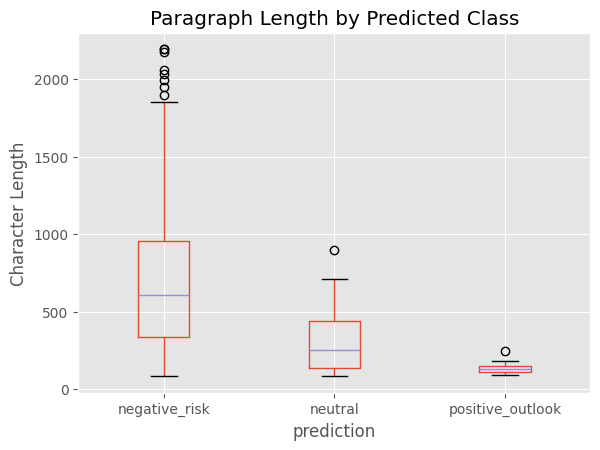

In [144]:
paragraphs_df.boxplot(column="text_length", by="prediction")
plt.title("Paragraph Length by Predicted Class")
plt.suptitle("")
plt.ylabel("Character Length")
plt.show()

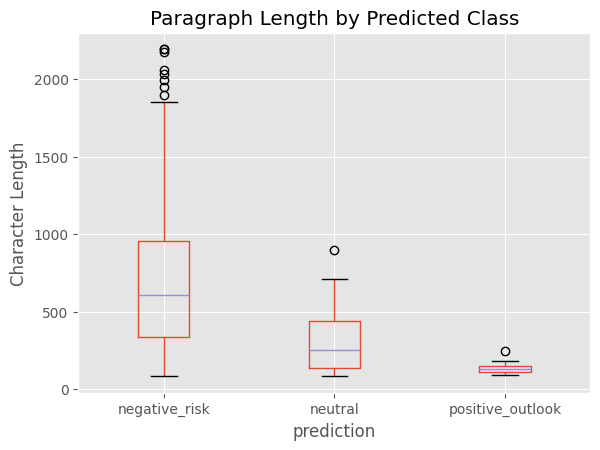

In [145]:
paragraphs_df.boxplot(column="text_length", by="prediction")
plt.title("Paragraph Length by Predicted Class")
plt.suptitle("")
plt.ylabel("Character Length")
plt.show()

In [146]:
section_col = paragraphs_df["section"].fillna("unknown_section")

section_pred = pd.crosstab(section_col, paragraphs_df["prediction"])
section_pred.head(20)

prediction,negative_risk,neutral,positive_outlook
section,,,
unknown_section,286,25,10


In [147]:
section_pred_pct = pd.crosstab(
    section_col,
    paragraphs_df["prediction"],
    normalize="index"
).round(3)

section_pred_pct.head(20)

prediction,negative_risk,neutral,positive_outlook
section,,,
unknown_section,0.891,0.078,0.031


## Exporting Analysis-Ready Outputs

The final export saves enriched filing-level outputs so they can be reused outside the notebook for:

- reporting,
- visualization,
- downstream quantitative analysis,
- or portfolio-style project presentation.

This makes the notebook not only exploratory, but also reproducible and reusable.

In [148]:
filing_summary_df.to_csv("../data/reports/filing_prediction_summary_enriched.csv", index=False)

# Key Findings

This analysis highlights several key insights:

1. The corpus is dominated by negative risk language (~89%), reflecting the nature of SEC risk disclosures.

2. The model demonstrates strong confidence when identifying risk statements, with average confidence around 0.93.

3. Filing-level risk scores are consistently high across companies, suggesting similar disclosure practices.

4. High-confidence risk paragraphs emphasize common themes including product reliability, intellectual property, competition, and regulatory risk.

5. Future improvements to the pipeline could incorporate section extraction to enable more granular analysis of risk language within filings.

Overall, the results demonstrate that transformer-based language models can effectively identify and summarize risk disclosures within SEC filings.